# Explore here

In [46]:
import pandas as pd
adult_income_df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv")
adult_income_df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [47]:
adult_income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [48]:
import numpy as np
adult_income_df.replace('?', np.nan, inplace=True)
adult_income_df['high_income'] = adult_income_df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [49]:
def contar_NAN(ds):
    conteo = ds.isna().sum()
    return conteo
    

contiene_nan = adult_income_df.isna().any()

ds_NaN = pd.concat([contiene_nan,contar_NAN(adult_income_df)], axis=1)
ds_NaN.columns = ['Contiene NaN','Cantidad']
ds_NaN

,Contiene NaN,Cantidad
age,False,0
workclass,True,1836
fnlwgt,False,0
education,False,0
education.num,False,0
marital.status,False,0
occupation,True,1843
relationship,False,0
race,False,0
sex,False,0


In [50]:
df_adult_inc = adult_income_df.dropna()


In [51]:
contiene_nan_2 = df_adult_inc.isna().any()

ds_NaN_2 = pd.concat([contiene_nan_2,contar_NAN(df_adult_inc)], axis=1)
ds_NaN_2.columns = ['Contiene NaN','Cantidad']
ds_NaN_2

,Contiene NaN,Cantidad
age,False,0
workclass,False,0
fnlwgt,False,0
education,False,0
education.num,False,0
marital.status,False,0
occupation,False,0
relationship,False,0
race,False,0
sex,False,0


In [52]:
#Filtrar por las columnas de formato objet

#columnas numéricas
cols_num = df_adult_inc._get_numeric_data().columns

#columnas categóricas se pueden representar como la diferencia entre el total de columnas y las columnas numéricas
cols = df_adult_inc.columns
cols_cat = list(set(cols)-set(cols_num))
cols_cat

['workclass',
 'native.country',
 'occupation',
 'sex',
 'relationship',
 'education',
 'income',
 'marital.status',
 'race']

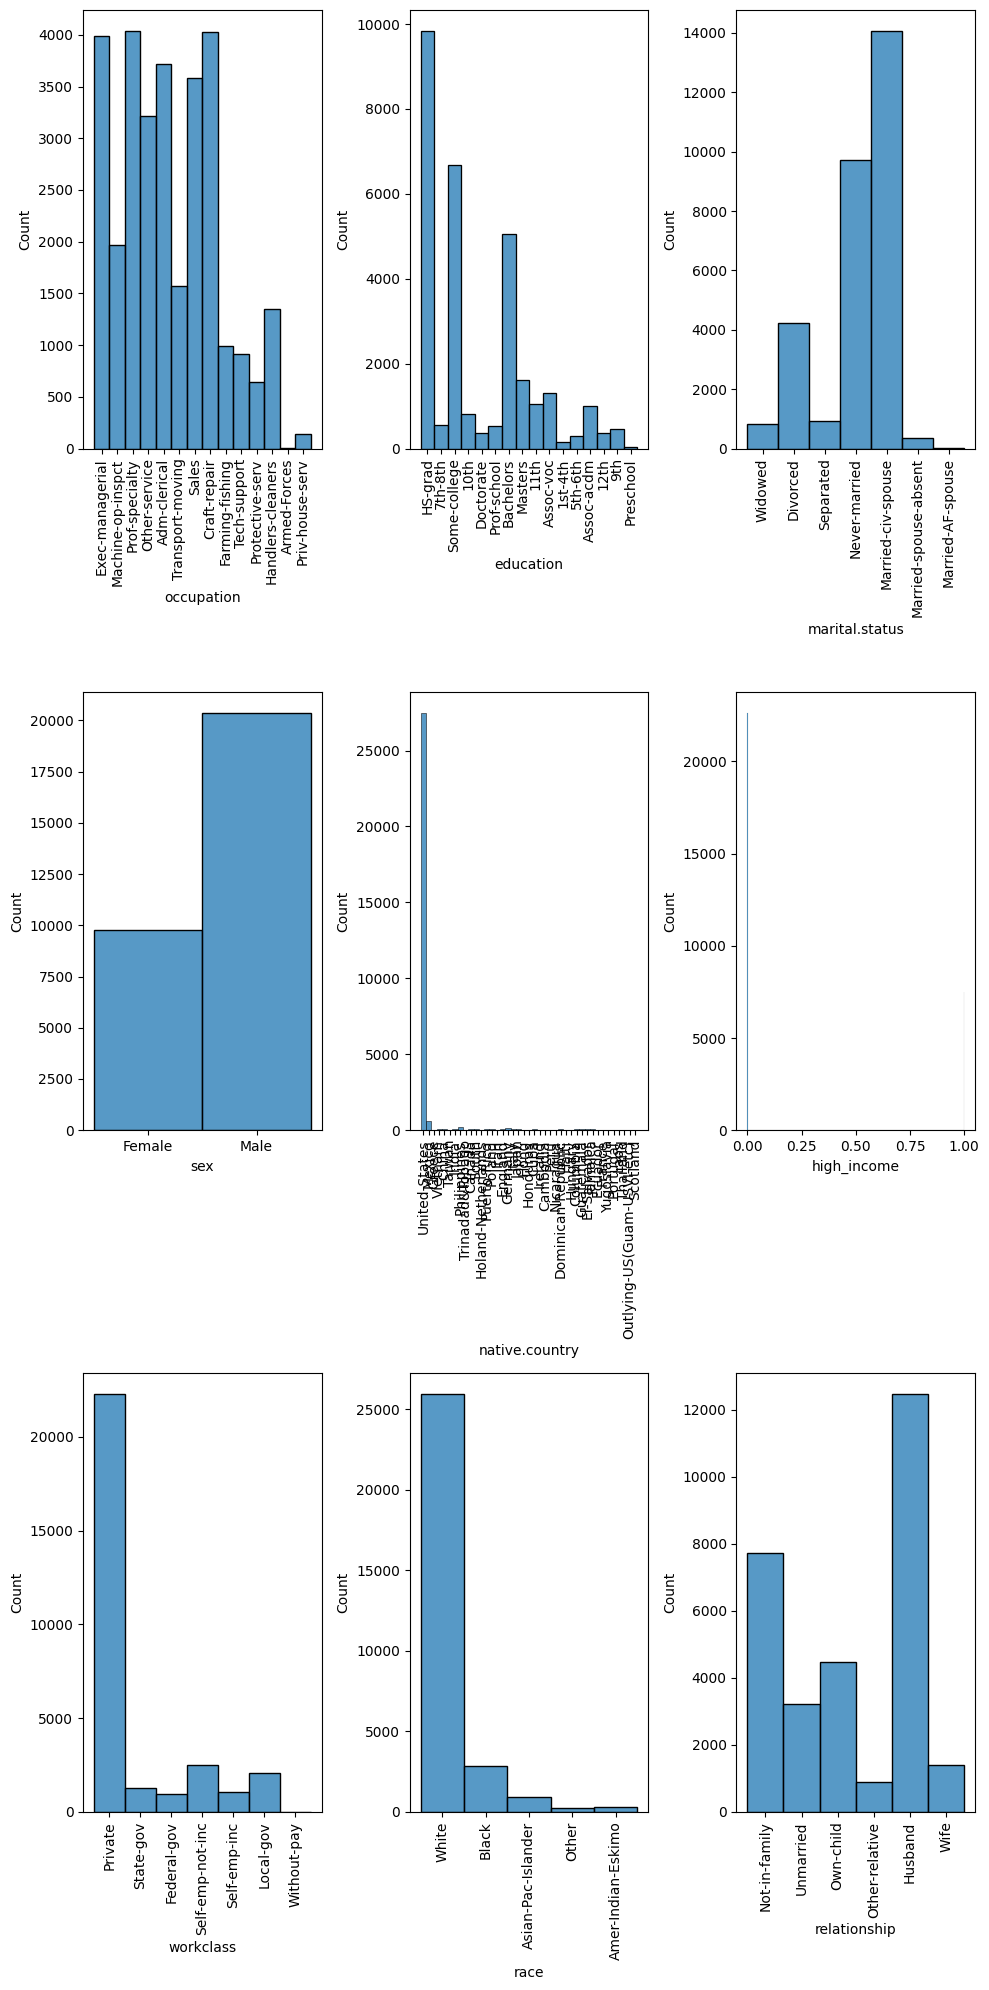

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3,3,figsize=(10,20))
#histogramas de las variables
sns.histplot(ax= axis[0,0],data=df_adult_inc,x='occupation')
sns.histplot(ax= axis[0,1],data=df_adult_inc,x='education')#.set_xticks([])
sns.histplot(ax= axis[0,2],data=df_adult_inc,x='marital.status')#.set_xticks([])
sns.histplot(ax= axis[1,0],data=df_adult_inc,x='sex')
sns.histplot(ax= axis[1,1],data=df_adult_inc,x='native.country')
sns.histplot(ax= axis[1,2],data=df_adult_inc,x='high_income')
sns.histplot(ax= axis[2,0],data=df_adult_inc,x='workclass')
sns.histplot(ax= axis[2,1],data=df_adult_inc,x='race')
sns.histplot(ax= axis[2,2],data=df_adult_inc,x='relationship')

axis[0, 0].tick_params(axis='x', rotation=90)
axis[0, 1].tick_params(axis='x', rotation=90)
axis[0, 2].tick_params(axis='x', rotation=90)
axis[1, 1].tick_params(axis='x', rotation=90)
axis[2, 0].tick_params(axis='x', rotation=90)
axis[2, 1].tick_params(axis='x', rotation=90)
axis[2, 2].tick_params(axis='x', rotation=90)
#para borrar graficos en blanco
#fig.delaxes(axis[1,2])
#plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


In [54]:
cols_num

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week', 'high_income'],
      dtype='object')

<Axes: xlabel='hours.per.week'>

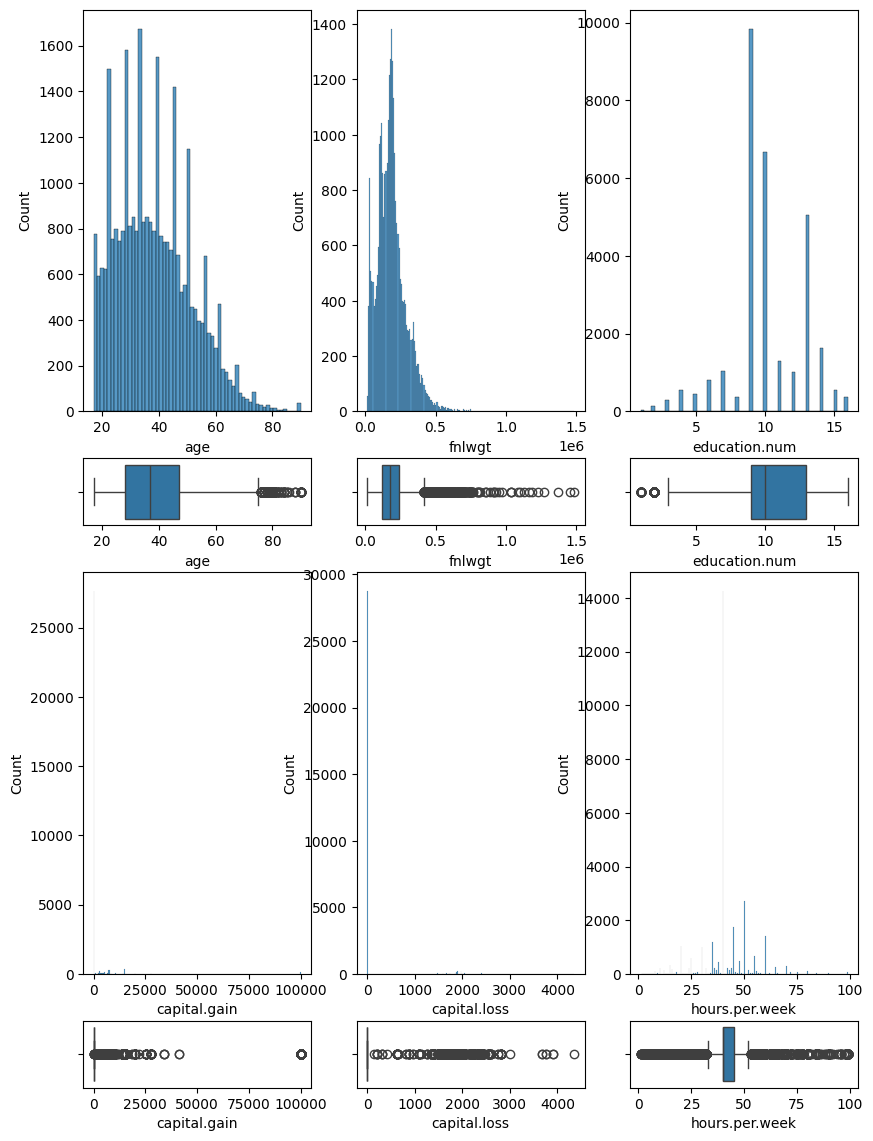

In [55]:
fig, axis = plt.subplots(4,3,figsize=(10,14),gridspec_kw={"height_ratios":[6,1,6,1]})

sns.histplot(ax= axis[0,0],data=df_adult_inc,x='age')
sns.boxplot(ax=axis[1,0],data=df_adult_inc,x='age')
sns.histplot(ax= axis[0,1],data=df_adult_inc,x='fnlwgt')#.set_xlim(0,60)
sns.boxplot(ax=axis[1,1],data=df_adult_inc,x='fnlwgt')#.set_xlim(0,60)
sns.histplot(ax= axis[0,2],data=df_adult_inc,x='education.num')#.set_xlim(0,60)
sns.boxplot(ax=axis[1,2],data=df_adult_inc,x='education.num')#.set_xlim(0,60)

sns.histplot(ax= axis[2,0],data=df_adult_inc,x='capital.gain')
sns.boxplot(ax=axis[3,0],data=df_adult_inc,x='capital.gain')
sns.histplot(ax= axis[2,1],data=df_adult_inc,x='capital.loss')#.set_xlim(0,100)
sns.boxplot(ax=axis[3,1],data=df_adult_inc,x='capital.loss')#.set_xlim(0,100)
sns.histplot(ax= axis[2,2],data=df_adult_inc,x='hours.per.week')#.set_xlim(0,100)
sns.boxplot(ax=axis[3,2],data=df_adult_inc,x='hours.per.week')#.set_xlim(0,100)

In [56]:

#agrega una variable numerica terminada en "_num" en el dataframe, que luego utilizafemos para reemplazar las variables categóricas
# si no agregamos la terminación "_num", la variable categorica será reemplazada por una numérica
for col in cols_cat:
    
    df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
df_adult_inc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 30162 non-null  int64 
 1   workclass           30162 non-null  object
 2   fnlwgt              30162 non-null  int64 
 3   education           30162 non-null  object
 4   education.num       30162 non-null  int64 
 5   marital.status      30162 non-null  object
 6   occupation          30162 non-null  object
 7   relationship        30162 non-null  object
 8   race                30162 non-null  object
 9   sex                 30162 non-null  object
 10  capital.gain        30162 non-null  int64 
 11  capital.loss        30162 non-null  int64 
 12  hours.per.week      30162 non-null  int64 
 13  native.country      30162 non-null  object
 14  income              30162 non-null  object
 15  high_income         30162 non-null  int64 
 16  workclass_num       30162 n

/tmp/ipykernel_1649/88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
/tmp/ipykernel_1649/88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
/tmp/ipykernel_1649/88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [57]:
df_num = df_adult_inc.drop(cols_cat,axis=1)
df_num.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,high_income,workclass_num,native.country_num,occupation_num,sex_num,relationship_num,education_num,income_num,marital.status_num,race_num
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238,0.248922,0.841357,1.211922,4.360221,0.675685,2.376931,3.683542,0.248922,3.100126,0.213646
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984,0.432396,1.582725,5.161287,3.097132,0.468126,1.758105,3.807782,0.432396,1.161214,0.622172
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000,2.000000,0.000000,3.000000,0.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000,0.000000,1.000000,0.000000,7.000000,1.000000,4.000000,6.000000,0.000000,4.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000,6.000000,40.000000,13.000000,1.000000,5.000000,15.000000,1.000000,6.000000,4.000000


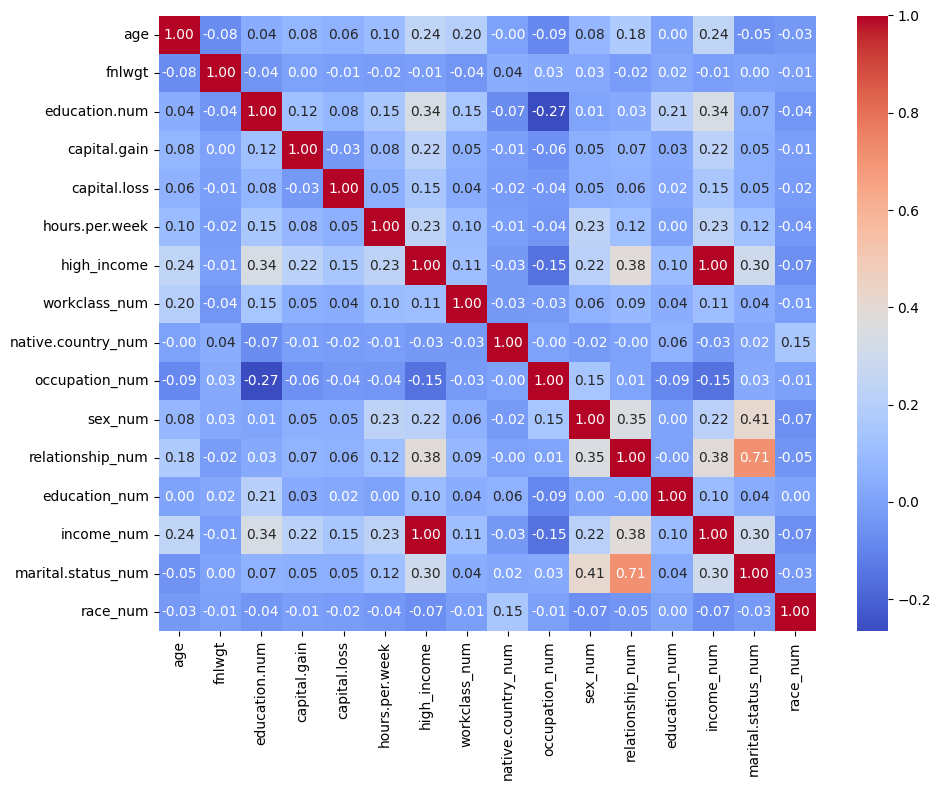

In [58]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot = True, fmt = ".2f", cmap='coolwarm', annot_kws={"size": 10})
plt.tight_layout()
plt.show()


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Selección de variables y preprocesamiento
# Cargar y limpiar los datos
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv")
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)
df['income'] = df['income'].str.strip()
df['high_income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [60]:
# Selección de variables y preprocesamiento
features = ['age', 'education', 'marital.status', 'occupation', 'hours.per.week', 'sex', 'native.country']
X = df[features]
y = df['high_income']

numeric_features = ['age', 'hours.per.week']
categorical_features = ['education', 'marital.status', 'occupation', 'sex', 'native.country']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [61]:
# Pipeline de modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
# Función de recomendación
def recommend_trajectory(user_profile):
    """
    user_profile debe ser un diccionario con keys:
    - age, education, marital.status, occupation, hours.per.week, sex, native.country
    """
    user_df = pd.DataFrame([user_profile])
    prediction = model.predict(user_df)[0]
    prob = model.predict_proba(user_df)[0][1]
    if prediction == 1:
        return f"✅ Con este perfil, tu probabilidad de ganar más de 50K es del {prob*100:.1f}%."
    else:
        return f"⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del {prob*100:.1f}%. Considera mejorar tu educación o cambiar de ocupación."

In [68]:
df['native.country'].unique()

array(['United-States', 'Mexico', 'Greece', 'Vietnam', 'China', 'Taiwan',
       'India', 'Philippines', 'Trinadad&Tobago', 'Canada', 'South',
       'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran', 'England',
       'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba', 'Ireland',
       'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic', 'Haiti',
       'Hungary', 'Columbia', 'Guatemala', 'El-Salvador', 'Jamaica',
       'Ecuador', 'France', 'Yugoslavia', 'Portugal', 'Laos', 'Thailand',
       'Outlying-US(Guam-USVI-etc)', 'Scotland'], dtype=object)

In [69]:
df['education'].unique()

array(['HS-grad', '7th-8th', 'Some-college', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-voc',
       '1st-4th', '5th-6th', 'Assoc-acdm', '12th', '9th', 'Preschool'],
      dtype=object)

In [71]:
df['occupation'].unique()

array(['Exec-managerial', 'Machine-op-inspct', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Transport-moving', 'Sales',
       'Craft-repair', 'Farming-fishing', 'Tech-support',
       'Protective-serv', 'Handlers-cleaners', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [76]:
# Simulación de usuario
simulated_user = {
    "age": 25,
    "education": "Doctorate",
    "marital.status": "Never-married",
    "occupation": "Prof-specialty",
    "hours.per.week": 40,
    "sex": "Male",
    "native.country": "Ecuador"
}
recommend_trajectory(simulated_user)

'⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del 12.5%. Considera mejorar tu educación o cambiar de ocupación.'